In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [3]:
df = pd.read_csv("../data/g_transit/clean/stations.csv")

In [4]:
df.head()

,name,docks,bikeable_infrastructure,trips,lat,lon,trips_per_dock,nearest_dining_hall_m,nearest_amenity_m,nearest_park_m,...,count_retail_275m,count_retail_550m,avg_dist_3_retail_m,nearest_bikeshare_station_m,avg_dist_3_stations,bikeshare_station_count_within_275m,bikeshare_station_count_within_550m,nearest_transit_stop_distance_m,count_transit_stop_275m,count_transit_stop_550m
0,barton_springs_pool,11,2.0,3613,30.264500,-97.771359,328.454545,3903.249201,48.268192,0.000000,...,3,8,148.193271,330.746518,565.399790,0,2,335.767553,0,4
1,barton_springs_bouldin_at_palmer_auditorium,15,3.0,5037,30.259660,-97.753445,335.800000,3047.383588,201.123665,4.855305,...,6,18,144.450498,359.120832,475.723320,0,2,32.831087,5,19
2,barton_springs_kinney,11,3.0,2774,30.261928,-97.761131,252.181818,3307.996951,99.765738,271.389154,...,22,40,55.541683,543.802429,714.325309,0,1,60.854324,3,10
3,cesar_chavez_congress,11,3.0,3695,30.263344,-97.745094,335.909091,2325.915667,90.330300,0.000000,...,48,165,107.642891,171.537280,249.345314,2,4,119.139106,3,12
4,dean_keeton_park_place,15,3.0,4333,30.289310,-97.733037,288.866667,661.140420,103.696535,17.800356,...,1,19,284.887940,337.181657,407.816601,0,3,143.448003,6,23


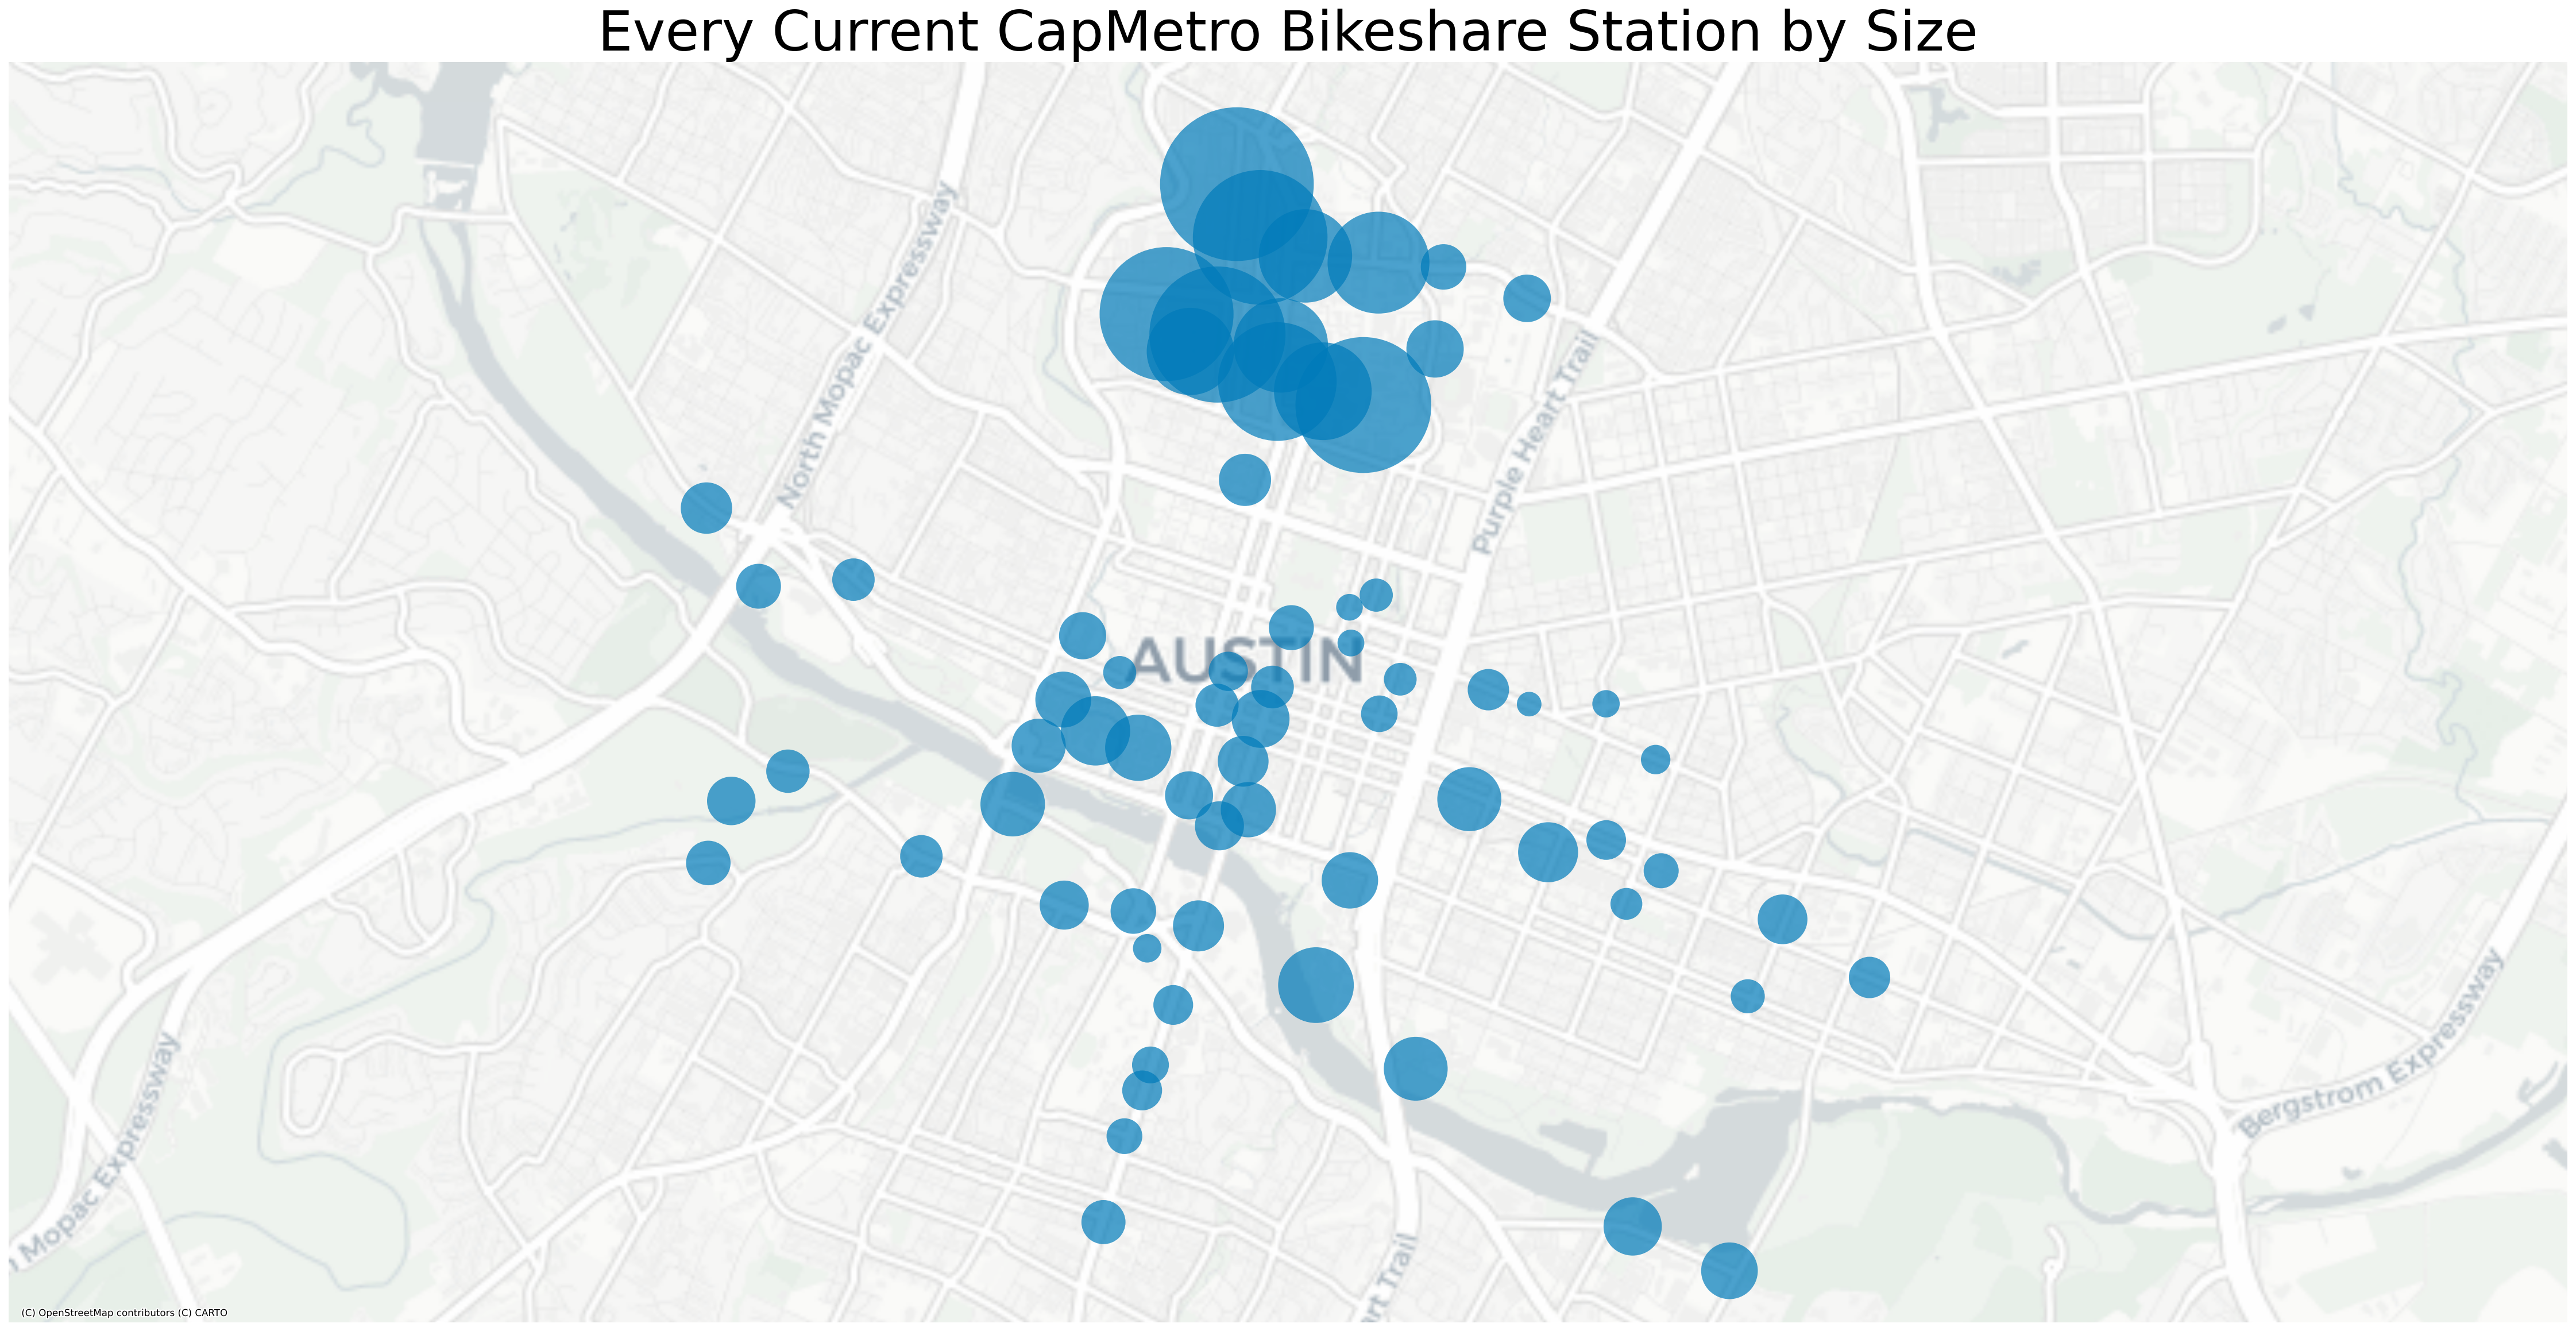

In [5]:
df = df.dropna(subset=["lat", "lon", "trips_per_dock"]).copy()

# Convert to GeoDataFrame from lon/lat
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326"
)

# Reproject to Web Mercator for contextily basemap
gdf = gdf.to_crs(epsg=3857)

# Bubble size scaling
size_scale = 5
sizes = gdf["trips_per_dock"] * size_scale

plt.close("all")
fig, ax = plt.subplots(figsize=(30, 20), dpi=150)

gdf.plot(ax=ax, markersize=sizes, color="#007bba", alpha=0.7, edgecolor="none")

# Zoom out more by expanding bounds
xmin, ymin, xmax, ymax = gdf.total_bounds
xpad = (xmax - xmin) * 0.6
ypad = (ymax - ymin) * 0.08

# Shift map ever so slightly higher
yshift = (ymax - ymin) * 0.0325

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad + yshift, ymax + ypad + yshift)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron,
    # optional: zoom_adjust=-1
)
plt.title("Every Current CapMetro Bikeshare Station by Size", fontsize=46)
ax.set_axis_off()
plt.tight_layout()
plt.show()